In [1]:
# forçando o repositorio a encontrar src
import sys
import os
sys.path.append(os.path.abspath('..'))

In [2]:
import pandas as pd 
import os 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
#from utils.analytics.Plot3d import Plot3d

In [3]:
data_path = os.path.join('data', 'raw', 'dados_completos.csv')
df = pd.read_csv("C:\\Users\\souza\\OneDrive\\Área de Trabalho\\modelagem inadimplencia\\data\\raw\\dados_completos.csv")
df = df.rename(columns={'4393': 'Confiança_consumidor', 
                        '21084':'Inadimplencia_PF', 
                        '24369':'Desemprego',
                        '27640':'Juros_nao_rotativos_PF',
                        '4390':'SELIC', 
                        '24364':'IBC-Br'})
df = df.set_index('data')
df = df.dropna()
X = df.drop(['Inadimplencia_PF'], axis=1)
# X.insert(0, 'intercepto', 1)
X_train = X.loc['2012-03-01':'2026-01-01']
X_test = X.loc['2026-02-01':]
y = df['Inadimplencia_PF']
y_train = y.loc['2012-03-01':'2026-01-01']
y_test = y.loc['2026-02-01':]


In [ ]:
# criando funçao para previsao direta do modelo
def model_MQO(X:pd.DataFrame):
    return 10.044700 + (0.019627*X['Confiança_consumidor']) + (-0.165325 * X['Desemprego']) + (1.095709*X['Juros_nao_rotativos_PF'])+(0.111168*X['SELIC'])+(-0.089431*X['IBC-Br'])

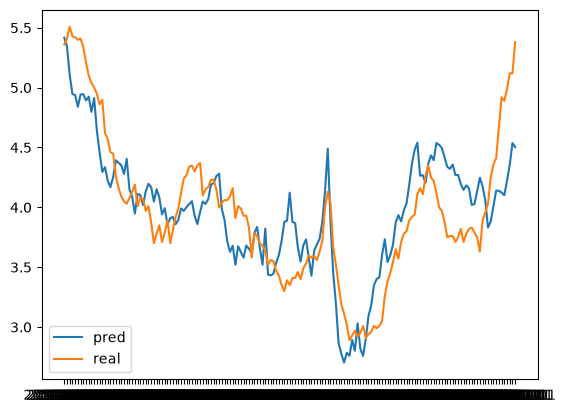

In [25]:
y_pred_train = model_MQO(X_train)
plt.plot(y_pred_train, label='pred')
plt.plot(y_train, label='real')
plt.legend()



In [17]:
y_pred_train.std()

np.float64(0.5074863022262377)